# Классификация токсичных комментариев (NLP)

**Описание проекта**   
Интернет-магазин «Викишоп» запускает новый сервис. Теперь пользователи могут редактировать и дополнять описания товаров, как в вики-сообществах. То есть клиенты предлагают свои правки и комментируют изменения других. Магазину нужен инструмент, который будет искать токсичные комментарии и отправлять их на модерацию. 

**Цель проекта**   
Обучить модель классифицировать комментарии на позитивные и негативные. Построить модель со значением метрики качества *F1* не меньше 0.75 (на валидационной выборке)

**Описание данных:**   
Датасет с комментариями пользователей. Более 150 000 строк

**Содержание:**  
- [1. Подготовка данных](#подготовка)
- [2. Обучение моделей](#обучение)
- [3. Выводы](#выводы)

**Общий вывод:**   
По результатам обучения 2 моделей (с разными векторизациями текстов) при использовании 13000 строк (примерно 10% датасета) лучшей показала себя LogisticRegression + Bag of words

<a id="подготовка"></a> 
## Подготовка данных

In [1]:
import numpy as np
import pandas as pd
import spacy
import re
import nltk
from nltk.corpus import stopwords as nltk_stopwords
from sklearn.linear_model import LogisticRegression
from catboost import CatBoostClassifier, Pool
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold
from sklearn.metrics import f1_score, classification_report, confusion_matrix
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer

RANDOM_STATE = 42

nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\Roman\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

Посмотрим на датасет. Сразу избавимся от колонки Unnamed: 0, видимо это старые индексы

In [2]:
try:
    df = pd.read_csv('toxic_comments.csv', index_col = [0])
except:
    df = pd.read_csv('https://code.s3.yandex.net/datasets/toxic_comments.csv', index_col = [0])

In [3]:
def opening(df):
    print('ПЕРВЫЕ ПЯТЬ СТРОК')
    display(df.head())
    
    print('ИНФОРМАЦИЯ О ДАННЫХ')
    df.info()
    print('\n')
    
    print('КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ')
    print(df.isna().sum(), '\n')
    
    print('ОПИСАНИЕ ЧИСЛОВЫХ ДАННЫХ')
    print(df.describe(), '\n')
    
    print('КОЛИЧЕСТВО ДУБЛИКАТОВ')
    print(df.duplicated().sum(), '\n')
    
    print('toxic, %')
    print((df['toxic'].value_counts() / df.shape[0]).round(3) * 100, '\n')
        
    print('РАСПРЕДЕЛЕНИЕ ДАННЫХ КОЛИЧЕСТВЕННЫХ СТОЛБЦОВ')
    df.hist(figsize = (10,5))

ПЕРВЫЕ ПЯТЬ СТРОК


,text,toxic
0,Explanation\nWhy the edits made under my usern...,0
1,D'aww! He matches this background colour I'm s...,0
2,"Hey man, I'm really not trying to edit war. It...",0
3,"""\nMore\nI can't make any real suggestions on ...",0
4,"You, sir, are my hero. Any chance you remember...",0


ИНФОРМАЦИЯ О ДАННЫХ
<class 'pandas.core.frame.DataFrame'>
Index: 159292 entries, 0 to 159450
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   text    159292 non-null  object
 1   toxic   159292 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 3.6+ MB


КОЛИЧЕСТВО ПРОПУЩЕННЫХ ЗНАЧЕНИЙ
text     0
toxic    0
dtype: int64 

ОПИСАНИЕ ЧИСЛОВЫХ ДАННЫХ
               toxic
count  159292.000000
mean        0.101612
std         0.302139
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max         1.000000 

КОЛИЧЕСТВО ДУБЛИКАТОВ
0 

toxic, %
toxic
0    89.8
1    10.2
Name: count, dtype: float64 

РАСПРЕДЕЛЕНИЕ ДАННЫХ КОЛИЧЕСТВЕННЫХ СТОЛБЦОВ


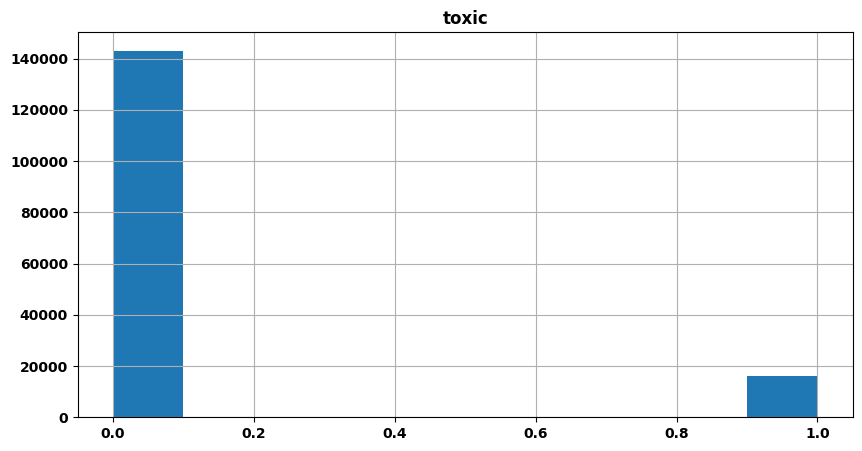

In [4]:
opening(df)

Для ускорения обучения возьмем небольшое случайное количество строк

In [5]:
df_sample = df.sample(n=13000, random_state=RANDOM_STATE)

print (df_sample['toxic'].value_counts() / df_sample.shape[0] * 100, '\n')
print(df_sample.shape)

toxic
0    89.823077
1    10.176923
Name: count, dtype: float64 

(13000, 2)


In [6]:
nlp = spacy.load("en_core_web_sm")

def lemmatize(text):
    text = re.sub(r'[^a-zA-z]', ' ', text)
    text = text.lower()
    text = " ".join(text.split())
    
    doc = nlp(text) 
    lemm_text =  " ".join([token.lemma_ for token in doc])
    return lemm_text

df_sample['lemm_text'] = df_sample['text'].apply(lemmatize)

df_sample.head()

,text,toxic,lemm_text
31055,"Sometime back, I just happened to log on to ww...",0,sometime back I just happen to log on to www i...
102929,"""\n\nThe latest edit is much better, don't mak...",0,the late edit be much well don t make this art...
67385,""" October 2007 (UTC)\n\nI would think you'd be...",0,october utc I would think you d be able to get...
81167,Thanks for the tip on the currency translation...,0,thank for the tip on the currency translation ...
90182,I would argue that if content on the Con in co...,0,I would argue that if content on the con in co...


**ИТОГ ПО РАЗДЕЛУ:**  
1) Датасет с комментариями клиентов. Сразу избавляемся от старых индексов. Остается 2 столбца. Первый - с комментариями (159292 записи). Второй - с оценкой токсичности (0 - нет, 1 - да)  
2) Пропущенных значений нет. Дубликатов нет. 89,8% не токсичных ответов, а 10,2% токсичные  
3) Берем выборку в 13000 строк для более быстрой работы ноутбука  
4) Создаем третий столбец с лемматизированным текстом для английского языка

<a id="обучение"></a> 
## Обучение моделей

Разделим данные на тренировочную, валидационную и тестовую выборки

In [7]:
X = df_sample['lemm_text']
y = df_sample['toxic']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, random_state=RANDOM_STATE, stratify=y, test_size=0.1
)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_temp, y_temp, random_state=RANDOM_STATE, stratify=y_temp, test_size=0.1
)

**1.TF-ITF + LogisticRegression**

In [8]:
stopwords = list(nltk_stopwords.words('english'))

tfidf = TfidfVectorizer(stop_words = stopwords, ngram_range=(1,1))

X_train_tfidf = tfidf.fit_transform(X_train)
X_valid_tfidf = tfidf.transform(X_valid)
X_test_tfidf = tfidf.transform(X_test)

print("Размер обучающей матрицы:", X_train_tfidf.shape)
print("Размер валидационной матрицы:", X_valid_tfidf.shape)
print("Размер тестовой матрицы:", X_test_tfidf.shape)

model1 = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE)
model1.fit(X_train_tfidf, y_train)

y_pred_valid_tdidf = model1.predict(X_valid_tfidf)

f1_lr_tf = f1_score(y_valid, y_pred_valid_tdidf)

print(f"f1-score: {f1_lr_tf:.3f}")
print(classification_report(y_valid, y_pred_valid_tdidf))
print(confusion_matrix(y_valid, y_pred_valid_tdidf))

Размер обучающей матрицы: (10530, 29996)
Размер валидационной матрицы: (1170, 29996)
Размер тестовой матрицы: (1300, 29996)
f1-score: 0.722
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1051
           1       0.68      0.77      0.72       119

    accuracy                           0.94      1170
   macro avg       0.83      0.87      0.84      1170
weighted avg       0.94      0.94      0.94      1170

[[1007   44]
 [  27   92]]


**2.Bag of words + LogisticRegression**

In [9]:
vectorizer = CountVectorizer()

X_train_vec = vectorizer.fit_transform(X_train)
X_valid_vec = vectorizer.transform(X_valid)
X_test_vec = vectorizer.transform(X_test)

print("Размер обучающей матрицы:", X_train_vec.shape)
print("Размер валидационной матрицы:", X_valid_vec.shape)
print("Размер тестовой матрицы:", X_test_vec.shape)

model2 = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)
model2.fit(X_train_vec, y_train)

y_pred_valid_vec = model2.predict(X_valid_vec)

f1_lr_bag = f1_score(y_valid, y_pred_valid_vec)

print(f"f1-score: {f1_lr_bag:.3f}")
print(classification_report(y_valid, y_pred_valid_vec))
print(confusion_matrix(y_valid, y_pred_valid_vec))

Размер обучающей матрицы: (10530, 30130)
Размер валидационной матрицы: (1170, 30130)
Размер тестовой матрицы: (1300, 30130)
f1-score: 0.774
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1051
           1       0.74      0.81      0.77       119

    accuracy                           0.95      1170
   macro avg       0.86      0.89      0.87      1170
weighted avg       0.95      0.95      0.95      1170

[[1018   33]
 [  23   96]]


**3.CATBOOST (с сырым текстом)**

In [10]:
X2 = df_sample['text']
y2 = df_sample['toxic']

X_temp2, X_test2, y_temp2, y_test2 = train_test_split(
    X2, y2, test_size=0.1, random_state=RANDOM_STATE, stratify=y2
)
X_train2, X_valid2, y_train2, y_valid2 = train_test_split(
    X_temp2, y_temp2, test_size=0.1, random_state=RANDOM_STATE, stratify=y_temp2
)

X_train_cat1 = X_train2.reset_index(drop=True).to_frame(name='text')
X_valid_cat1 = X_valid2.reset_index(drop=True).to_frame(name='text')
X_test_cat1  = X_test2.reset_index(drop=True).to_frame(name='text')

y_train1 = y_train2.astype(int).reset_index(drop=True)
y_valid1 = y_valid2.astype(int).reset_index(drop=True)
y_test1  = y_test2.astype(int).reset_index(drop=True)

train_pool = Pool(data=X_train_cat1, label=y_train1, text_features=['text'])

valid_pool = Pool(data=X_valid_cat1, label=y_valid1, text_features=['text'])

model3 = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    border_count=64,
    class_weights=[1, 5],
    eval_metric='F1',
    use_best_model=True,
    random_seed=RANDOM_STATE,
    verbose=100
)

model3.fit(train_pool, eval_set=valid_pool)

y_pred_valid_cat = model3.predict(X_valid_cat1)

f1_cat = f1_score(y_valid1, y_pred_valid_cat)
print(f"f1-score: {f1_cat:.3f}")
print(classification_report(y_valid1, y_pred_valid_cat))
print(confusion_matrix(y_valid1, y_pred_valid_cat))

0:	learn: 0.7136607	test: 0.7874016	best: 0.7874016 (0)	total: 182ms	remaining: 1m 30s
100:	learn: 0.7464213	test: 0.7929104	best: 0.7970343 (92)	total: 5.01s	remaining: 19.8s
200:	learn: 0.7803644	test: 0.7958801	best: 0.8103131 (117)	total: 9.7s	remaining: 14.4s
300:	learn: 0.8279941	test: 0.8059981	best: 0.8130841 (235)	total: 14.6s	remaining: 9.67s
400:	learn: 0.8565331	test: 0.7939509	best: 0.8130841 (235)	total: 19.4s	remaining: 4.8s
499:	learn: 0.8802682	test: 0.7867299	best: 0.8130841 (235)	total: 24.3s	remaining: 0us

bestTest = 0.8130841121
bestIteration = 235

Shrink model to first 236 iterations.
f1-score: 0.707
              precision    recall  f1-score   support

           0       0.97      0.96      0.97      1051
           1       0.69      0.73      0.71       119

    accuracy                           0.94      1170
   macro avg       0.83      0.85      0.84      1170
weighted avg       0.94      0.94      0.94      1170

[[1011   40]
 [  32   87]]


**4.CATBOOST (c лемматизированным текстом)**

In [11]:
X_train_cat2 = X_train.reset_index(drop=True).to_frame(name='lemm_text')
X_valid_cat2 = X_valid.reset_index(drop=True).to_frame(name='lemm_text')
X_test_cat2  = X_test.reset_index(drop=True).to_frame(name='lemm_text')

y_train2 = y_train.astype(int).reset_index(drop=True)
y_valid2 = y_valid.astype(int).reset_index(drop=True)
y_test2  = y_test.astype(int).reset_index(drop=True)

train_pool = Pool(
    data=X_train_cat2,
    label=y_train2,
    text_features=['lemm_text']
)

valid_pool = Pool(
    data=X_valid_cat2,
    label=y_valid2,
    text_features=['lemm_text']
)

model4 = CatBoostClassifier(
    iterations=500,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=3,
    border_count=64,
    class_weights=[1, 5],
    eval_metric='F1',
    use_best_model=True,
    random_seed=RANDOM_STATE,
    verbose=100
)

model4.fit(train_pool, eval_set=valid_pool)

y_pred_valid_cat2 = model4.predict(X_valid_cat2)

f1_cat_lemm = f1_score(y_valid2, y_pred_valid_cat2)
print(f"f1-score: {f1_cat_lemm:.3f}")
print(classification_report(y_valid2, y_pred_valid_cat2))
print(confusion_matrix(y_valid2, y_pred_valid_cat2))

0:	learn: 0.7630641	test: 0.8054299	best: 0.8054299 (0)	total: 38.5ms	remaining: 19.2s
100:	learn: 0.8103277	test: 0.8617594	best: 0.8617594 (99)	total: 5.09s	remaining: 20.1s
200:	learn: 0.8417378	test: 0.8586762	best: 0.8625337 (103)	total: 9.75s	remaining: 14.5s
300:	learn: 0.8806225	test: 0.8602151	best: 0.8625337 (103)	total: 14.6s	remaining: 9.64s
400:	learn: 0.9049008	test: 0.8609865	best: 0.8625337 (103)	total: 19.3s	remaining: 4.77s
499:	learn: 0.9240246	test: 0.8648649	best: 0.8648649 (440)	total: 23.9s	remaining: 0us

bestTest = 0.8648648649
bestIteration = 440

Shrink model to first 441 iterations.
f1-score: 0.768
              precision    recall  f1-score   support

           0       0.98      0.97      0.97      1051
           1       0.73      0.81      0.77       119

    accuracy                           0.95      1170
   macro avg       0.86      0.89      0.87      1170
weighted avg       0.95      0.95      0.95      1170

[[1016   35]
 [  23   96]]


**5.CATBOOST (lemm+tf-idf)**

In [12]:
X_train_cat3 = pd.DataFrame(X_train_tfidf.toarray(), columns=[f'f{i}' for i in range(X_train_tfidf.shape[1])])
X_valid_cat3 = pd.DataFrame(X_valid_tfidf.toarray(), columns=[f'f{i}' for i in range(X_valid_tfidf.shape[1])])
X_test_cat3  = pd.DataFrame(X_test_tfidf.toarray(), columns=[f'f{i}' for i in range(X_test_tfidf.shape[1])])

y_train3 = y_train.astype(int).reset_index(drop=True)
y_valid3 = y_valid.astype(int).reset_index(drop=True)
y_test3  = y_test.astype(int).reset_index(drop=True)

model5 = CatBoostClassifier(
    iterations=500,     
    depth=6, 
    learning_rate=0.05,  
    l2_leaf_reg=3, 
    border_count=64, 
    class_weights=[1, 8],
    verbose=0,
    random_seed=RANDOM_STATE,
    use_best_model=True
)

model5.fit(X_train_cat3, y_train3, eval_set=(X_valid_cat3, y_valid3))

y_pred_valid_cat3 = model5.predict(X_valid_cat3)

f1_lemm_tf = f1_score(y_valid3, y_pred_valid_cat3)
print(f"f1-score: {f1_lemm_tf:.3f}")
print(classification_report(y_valid3, y_pred_valid_cat3))
print(confusion_matrix(y_valid3, y_pred_valid_cat3))

f1-score: 0.730
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1051
           1       0.72      0.74      0.73       119

    accuracy                           0.94      1170
   macro avg       0.85      0.85      0.85      1170
weighted avg       0.95      0.94      0.94      1170

[[1017   34]
 [  31   88]]


In [13]:
f1_df = pd.DataFrame(columns = ['Модель', 'F1-score'])
f1_df.loc[len(f1_df)] = ['(TF-IDF)', f1_lr_tf]
f1_df.loc[len(f1_df)] = ['LR (Bag of words)', f1_lr_bag]
f1_df.loc[len(f1_df)] = ['Catboost (сырой текст)', f1_cat]
f1_df.loc[len(f1_df)] = ['Catboost(lemm_text)', f1_cat_lemm]
f1_df.loc[len(f1_df)] = ['Catboost(lemm_text + tf-idf)', f1_lemm_tf]

f1_df

,Модель,F1-score
0,(TF-IDF),0.721569
1,LR (Bag of words),0.774194
2,Catboost (сырой текст),0.707317
3,Catboost(lemm_text),0.768000
4,Catboost(lemm_text + tf-idf),0.730290


**Лучшая модель на валидационной выборке : LR (Bag of words)  
Проверим на тестовой выборке**

In [14]:
X = df_sample['lemm_text']
y = df_sample['toxic']

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, random_state=RANDOM_STATE, stratify=y, test_size=0.1
)

vectorizer = CountVectorizer()

X_temp_final = vectorizer.fit_transform(X_temp)
X_test_final = vectorizer.transform(X_test)

print('Размер обучающей матрицы:', X_temp_final.shape)
print('Размер тестовой матрицы:', X_test_final.shape)

model2 = LogisticRegression(class_weight='balanced', random_state=RANDOM_STATE, max_iter=1000)
model2.fit(X_temp_final, y_temp)

y_pred_final = model2.predict(X_test_final)

f1_final = f1_score(y_test, y_pred_final)

print(f"f1-score: {f1_final:.3f}")
print(classification_report(y_test, y_pred_final))
print(confusion_matrix(y_test, y_pred_final))

Размер обучающей матрицы: (11700, 31822)
Размер тестовой матрицы: (1300, 31822)
f1-score: 0.745
              precision    recall  f1-score   support

           0       0.97      0.97      0.97      1168
           1       0.72      0.77      0.74       132

    accuracy                           0.95      1300
   macro avg       0.85      0.87      0.86      1300
weighted avg       0.95      0.95      0.95      1300

[[1128   40]
 [  30  102]]


<a id="выводы"></a> 
## Выводы

- Загружен датасет, проверен на пропуски / дубликаты, сброшены индексы. Взята только часть данных для сокращения времени обучения  
- Проведена лемматизация текста, удалены стоп слова для некоторых моделей  
- Обучены модели классификации с подбором гиперпараметров:
    - LogisticRegression + TF-IDF
    - LogisticRegression + Bag of words
    - Catboost (сырой текст)
    - Catboost(lemm_text)
    - Catboost(lemm_text + tf-idf)
- Выявлены лучшие параметры и получена оценка метрик F1 на валидационной выборке. Лучшей моделью оказалась LogisticRegression + Bag of words. Модель проверена еще и на тестовой выборке. Метрика F1 оказалась чуть ниже